=== [1. Simple Linear Regression Output] ===
Intercept (b0): 40.01
Coefficient (b1): 1.49
Mean Squared Error (MSE): 20.91
R-squared (R2 Score): 0.86


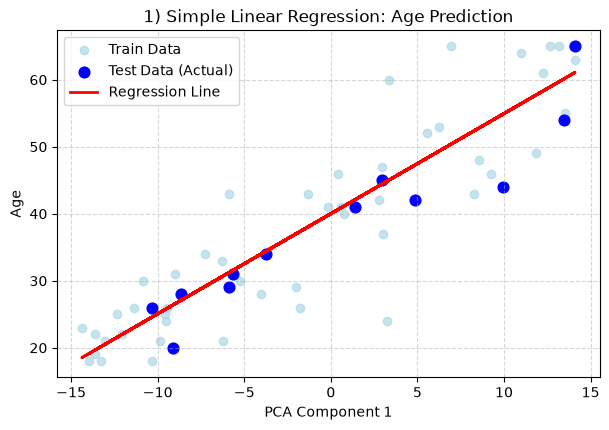

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#Lab1 Regression
#Simple Linear Regression
# 1. โหลดข้อมูล
df = pd.read_csv('face_dataset_v2.csv')

# 2. กำหนด Feature (X) และ Target (y)
X_simple = df[['PCA_Component_1']]
y = df['Age']

# 3. แบ่งข้อมูล Train 80% (48 ตัวอย่าง) และ Test 20% (12 ตัวอย่าง)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# 4. สร้างและเทรนโมเดล
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# 5. ทำนายผล
y_pred_s = model_simple.predict(X_test_s)

print("=== [1. Simple Linear Regression Output] ===")
print(f"Intercept (b0): {model_simple.intercept_:.2f}")
print(f"Coefficient (b1): {model_simple.coef_[0]:.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_s, y_pred_s):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test_s, y_pred_s):.2f}")

# 6. วาดกราฟจุดกระจาย (Scatter Plot) พร้อมเส้น Regression Line
plt.figure(figsize=(7, 4.5))
plt.scatter(X_train_s, y_train_s, color='lightblue', label='Train Data', alpha=0.7)
plt.scatter(X_test_s, y_test_s, color='blue', label='Test Data (Actual)', s=60)
plt.plot(X_simple, model_simple.predict(X_simple), color='red', linewidth=2, label='Regression Line')
plt.title('1) Simple Linear Regression: Age Prediction')
plt.xlabel('PCA Component 1')
plt.ylabel('Age')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== [2. Multiple Linear Regression Output] ===
Intercept (b0): 39.65
Coefficients: [1.44 0.63 0.06 0.63 0.32]
Mean Squared Error (MSE): 13.85
R-squared (R2 Score): 0.91


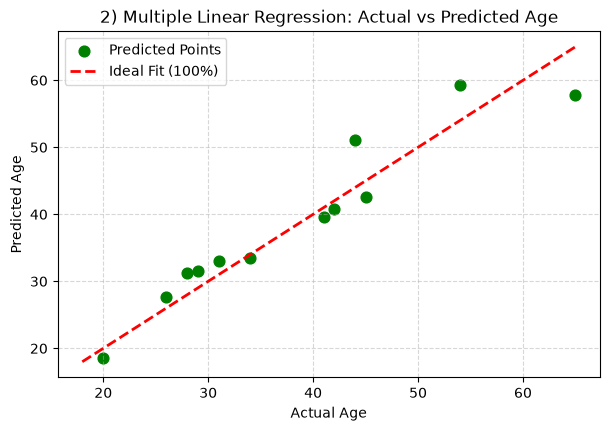

In [ ]:
#LAB 1: Regression
# Multiple Linear Regression 
# 1. กำหนด Features ทั้งหมด (X) และ Target (y)
X_multi = df[['PCA_Component_1', 'PCA_Component_2', 'PCA_Component_3', 'PCA_Component_4', 'PCA_Component_5']]
y = df['Age']

# 2. แบ่งข้อมูล Train / Test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# 3. สร้างและเทรนโมเดล
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# 4. ทำนายผล
y_pred_m = model_multi.predict(X_test_m)

print("=== [2. Multiple Linear Regression Output] ===")
print(f"Intercept (b0): {model_multi.intercept_:.2f}")
print(f"Coefficients: {np.round(model_multi.coef_, 2)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_m, y_pred_m):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test_m, y_pred_m):.2f}")

# 5. วาดกราฟเปรียบเทียบ ค่าจริง (Actual) vs ค่าทำนาย (Predicted)
plt.figure(figsize=(7, 4.5))
plt.scatter(y_test_m, y_pred_m, color='green', s=60, label='Predicted Points')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal Fit (100%)')
plt.title('2) Multiple Linear Regression: Actual vs Predicted Age')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
#LAB 1: Regression
#Age Prediction S
print("=== [3. Age Prediction Testing] ===")

# สมมติข้อมูลภาพใบหน้าใหม่ 1 ใบหน้า
new_face = pd.DataFrame([{
    'PCA_Component_1': 8.5,
    'PCA_Component_2': -2.1,
    'PCA_Component_3': 1.0,
    'PCA_Component_4': -0.5,
    'PCA_Component_5': 0.8
}])

# ทำนายผล
pred_simple = model_simple.predict(new_face[['PCA_Component_1']])[0]
pred_multi = model_multi.predict(new_face)[0]

print("ผลการทำนายอายุสำหรับภาพใบหน้าใหม่:")
print(f"• Simple Linear Regression  : {pred_simple:.1f} ปี")
print(f"• Multiple Linear Regression: {pred_multi:.1f} ปี")

# ตารางสรุปเปรียบเทียบประสิทธิภาพบน Test Set
comparison_df = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'MSE': [mean_squared_error(y_test_s, y_pred_s), mean_squared_error(y_test_m, y_pred_m)],
    'R2 Score': [r2_score(y_test_s, y_pred_s), r2_score(y_test_m, y_pred_m)]
})

print("\n--- ตารางเปรียบเทียบประสิทธิภาพโมเดล ---")
display(comparison_df)

=== [3. Age Prediction Testing] ===
ผลการทำนายอายุสำหรับภาพใบหน้าใหม่:
• Simple Linear Regression  : 52.7 ปี
• Multiple Linear Regression: 50.5 ปี

--- ตารางเปรียบเทียบประสิทธิภาพโมเดล ---


,Model,MSE,R2 Score
0,Simple Linear Regression,20.909209,0.861241
1,Multiple Linear Regression,13.848648,0.908097


In [1]:
#LAB 2: Classification
#Preparing Classification Data  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. โหลดข้อมูลจากไฟล์ CSV
df = pd.read_csv('face_dataset_v2.csv')

# 2. แปลงข้อมูลเชิงคุณภาพ (Categorical) ให้เป็นตัวเลข (Numeric)
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])

# 3. กำหนดตัวแปรต้น (X) และตัวแปรเป้าหมาย (y)
X = df[['PCA_Component_1', 'PCA_Component_2']]  # ใช้ 2 Components เพื่อนำไปพล็อตกราฟ 2D ได้
y = df['Gender_Encoded']

# 4. แบ่งข้อมูลออกเป็น ชุดฝึกสอน (80%) และ ชุดทดสอบ (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("จำนวนข้อมูล Train Set:", len(X_train))
print("จำนวนข้อมูล Test Set:", len(X_test))
print("การแปลงคลาส (Classes):", dict(zip(le.classes_, le.transform(le.classes_))))

จำนวนข้อมูล Train Set: 48
จำนวนข้อมูล Test Set: 12
การแปลงคลาส (Classes): {'Female': np.int64(0), 'Male': np.int64(1)}
